# SMOTE, ADASYN and BorderlineSMOTE

This notebook analyses the effect of **synthetic oversampling** methods on the
performance of tree-based ensembles for imbalanced classification, across 5 datasets.

The following strategies are compared against the six baseline ensemble models trained
on the original class distribution:

| Variant | Method | Target ratio |
|---|---|---|
| `smote_equal` | SMOTE | 1 : 1 |
| `smote_half` | SMOTE | 1 : 2 |
| `adasyn_equal` | ADASYN | 1 : 1 |
| `adasyn_half` | ADASYN | 1 : 2 |
| `bsmote1_equal` | BorderlineSMOTE type 1 | 1 : 1 |
| `bsmote1_half` | BorderlineSMOTE type 1 | 1 : 2 |
| `bsmote2_equal` | BorderlineSMOTE type 2 | 1 : 1 |
| `bsmote2_half` | BorderlineSMOTE type 2 | 1 : 2 |

Friedman + Nemenyi post-hoc tests are run per dataset per metric.
The pink band marks the RF baseline ± 1 std. Significance bars connect the best model
to every model that is statistically significantly worse (p < 0.05).

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df, create_fold_df, best_performance_summary
from functions.statistical_tests import apply_friedman_test, apply_nemenyi_test
from functions.plotting import compute_ylim, add_significance_bars

## Datasets

In [3]:
datasets = ["glass-0-1-4-6_vs_2", "pima", "ozone_level", "scene", "secom"]
base_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']

## Load results

In [4]:
base_dir = '../models/oversampling'

filename = '../models/ensembles/results'
with open(filename, 'rb') as f:
    scores_dict = pickle.load(f)

filename = '../models/ensembles/results_folds'
with open(filename, 'rb') as f:
    folds_dict = pickle.load(f)

# Restrict to the datasets analysed here
scores_dict = {d: dict(scores_dict[d]) for d in datasets}
folds_dict  = {d: dict(folds_dict[d])  for d in datasets}

In [5]:
oversamplers = [
    'smote_equal',
    'smote_half',
    'adasyn_equal',
    'adasyn_half',
    'bsmote1_equal',
    'bsmote1_half',
    'bsmote2_equal',
    'bsmote2_half',
]

# Each results file uses plain base-model names as keys (e.g. 'rf').
# We rename them with the oversampler suffix so all variants can coexist
# in the same scores_dict / folds_dict.
for ov in oversamplers:
    with open(f'{base_dir}/results_{ov}', 'rb') as f:
        tmp = pickle.load(f)
    with open(f'{base_dir}/results_folds_{ov}', 'rb') as f:
        tmp_f = pickle.load(f)
    for d in datasets:
        for base, vals in tmp.get(d, {}).items():
            scores_dict[d][f"{base}_{ov}"] = vals
        for base, vals in tmp_f.get(d, {}).items():
            folds_dict[d][f"{base}_{ov}"] = vals

In [6]:
# models list varies per dataset (pima is missing _half variants)
def models_for(dataset):
    return list(scores_dict[dataset].keys())

In [7]:
# test function
df = create_df(scores_dict, "pima", models_for("pima"))
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.825226,0.028167,0.667815,0.030591,0.557149,0.025363,0.900404,0.038127,0.688073,0.027185,0.524411,0.044805,0.777096,0.027878,0.158673,0.011113,0.767790,0.028615,0.299837,2.983096e-02
ada,0.843126,0.031516,0.697430,0.057319,0.615470,0.035371,0.839935,0.085553,0.707822,0.036805,0.562588,0.055682,0.793482,0.031753,0.199851,0.005056,0.790023,0.029850,0.463218,1.298785e-02
gbm,0.830616,0.023809,0.671512,0.035444,0.622691,0.066495,0.799088,0.075440,0.693521,0.021895,0.532487,0.042523,0.777004,0.018066,0.160856,0.014583,0.772960,0.017072,0.308507,9.588214e-02
cat,0.821662,0.030829,0.667280,0.059521,0.604297,0.048035,0.791099,0.067877,0.682299,0.036105,0.521070,0.052342,0.767114,0.032989,0.165606,0.018468,0.765206,0.034211,0.298082,9.095990e-02
lgbm,0.797061,0.033159,0.626786,0.048011,0.577617,0.032349,0.813178,0.046265,0.674091,0.023968,0.494945,0.040136,0.762789,0.021335,0.177314,0.017720,0.760198,0.020875,0.294131,3.869167e-02
xgb,0.822103,0.038136,0.666959,0.057643,0.650454,0.098987,0.764107,0.086219,0.692113,0.034566,0.535110,0.065035,0.775576,0.028664,0.158137,0.017130,0.770735,0.030219,0.372031,9.958395e-02
rf_smote_equal,0.503816,0.048831,0.350402,0.032069,0.351536,0.020730,0.954443,0.039289,0.513341,0.023650,0.175033,0.030718,0.566853,0.027009,0.423525,0.011297,0.529650,0.051696,0.776763,1.084105e-03
ada_smote_equal,0.516247,0.041316,0.358199,0.028558,0.357706,0.028269,0.986239,0.011256,0.524462,0.031722,0.209689,0.053605,0.569562,0.028780,0.313752,0.006650,0.515374,0.034308,0.594677,8.015243e-03
gbm_smote_equal,0.485203,0.035117,0.357775,0.025193,0.330542,0.020025,0.995652,0.008696,0.495937,0.022093,0.170809,0.042164,0.554554,0.025231,0.272023,0.005851,0.542895,0.036171,0.310871,1.554360e-02
cat_smote_equal,0.468581,0.039076,0.320519,0.040735,0.336621,0.021091,0.995652,0.008696,0.502727,0.023226,0.122419,0.054124,0.545749,0.021807,0.584249,0.026311,0.524148,0.032264,0.598064,2.927107e-01


## ROC-AUC Friedman test

In [8]:
friedman_rows = []
nemenyi_roc = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "roc")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_roc[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,96.785113,2.272168e-04
pima,115.350910,2.983706e-12
ozone_level,234.896915,9.613349e-25
scene,213.550338,3.758121e-21
secom,219.964627,3.206490e-22


## Plot ROC-AUC

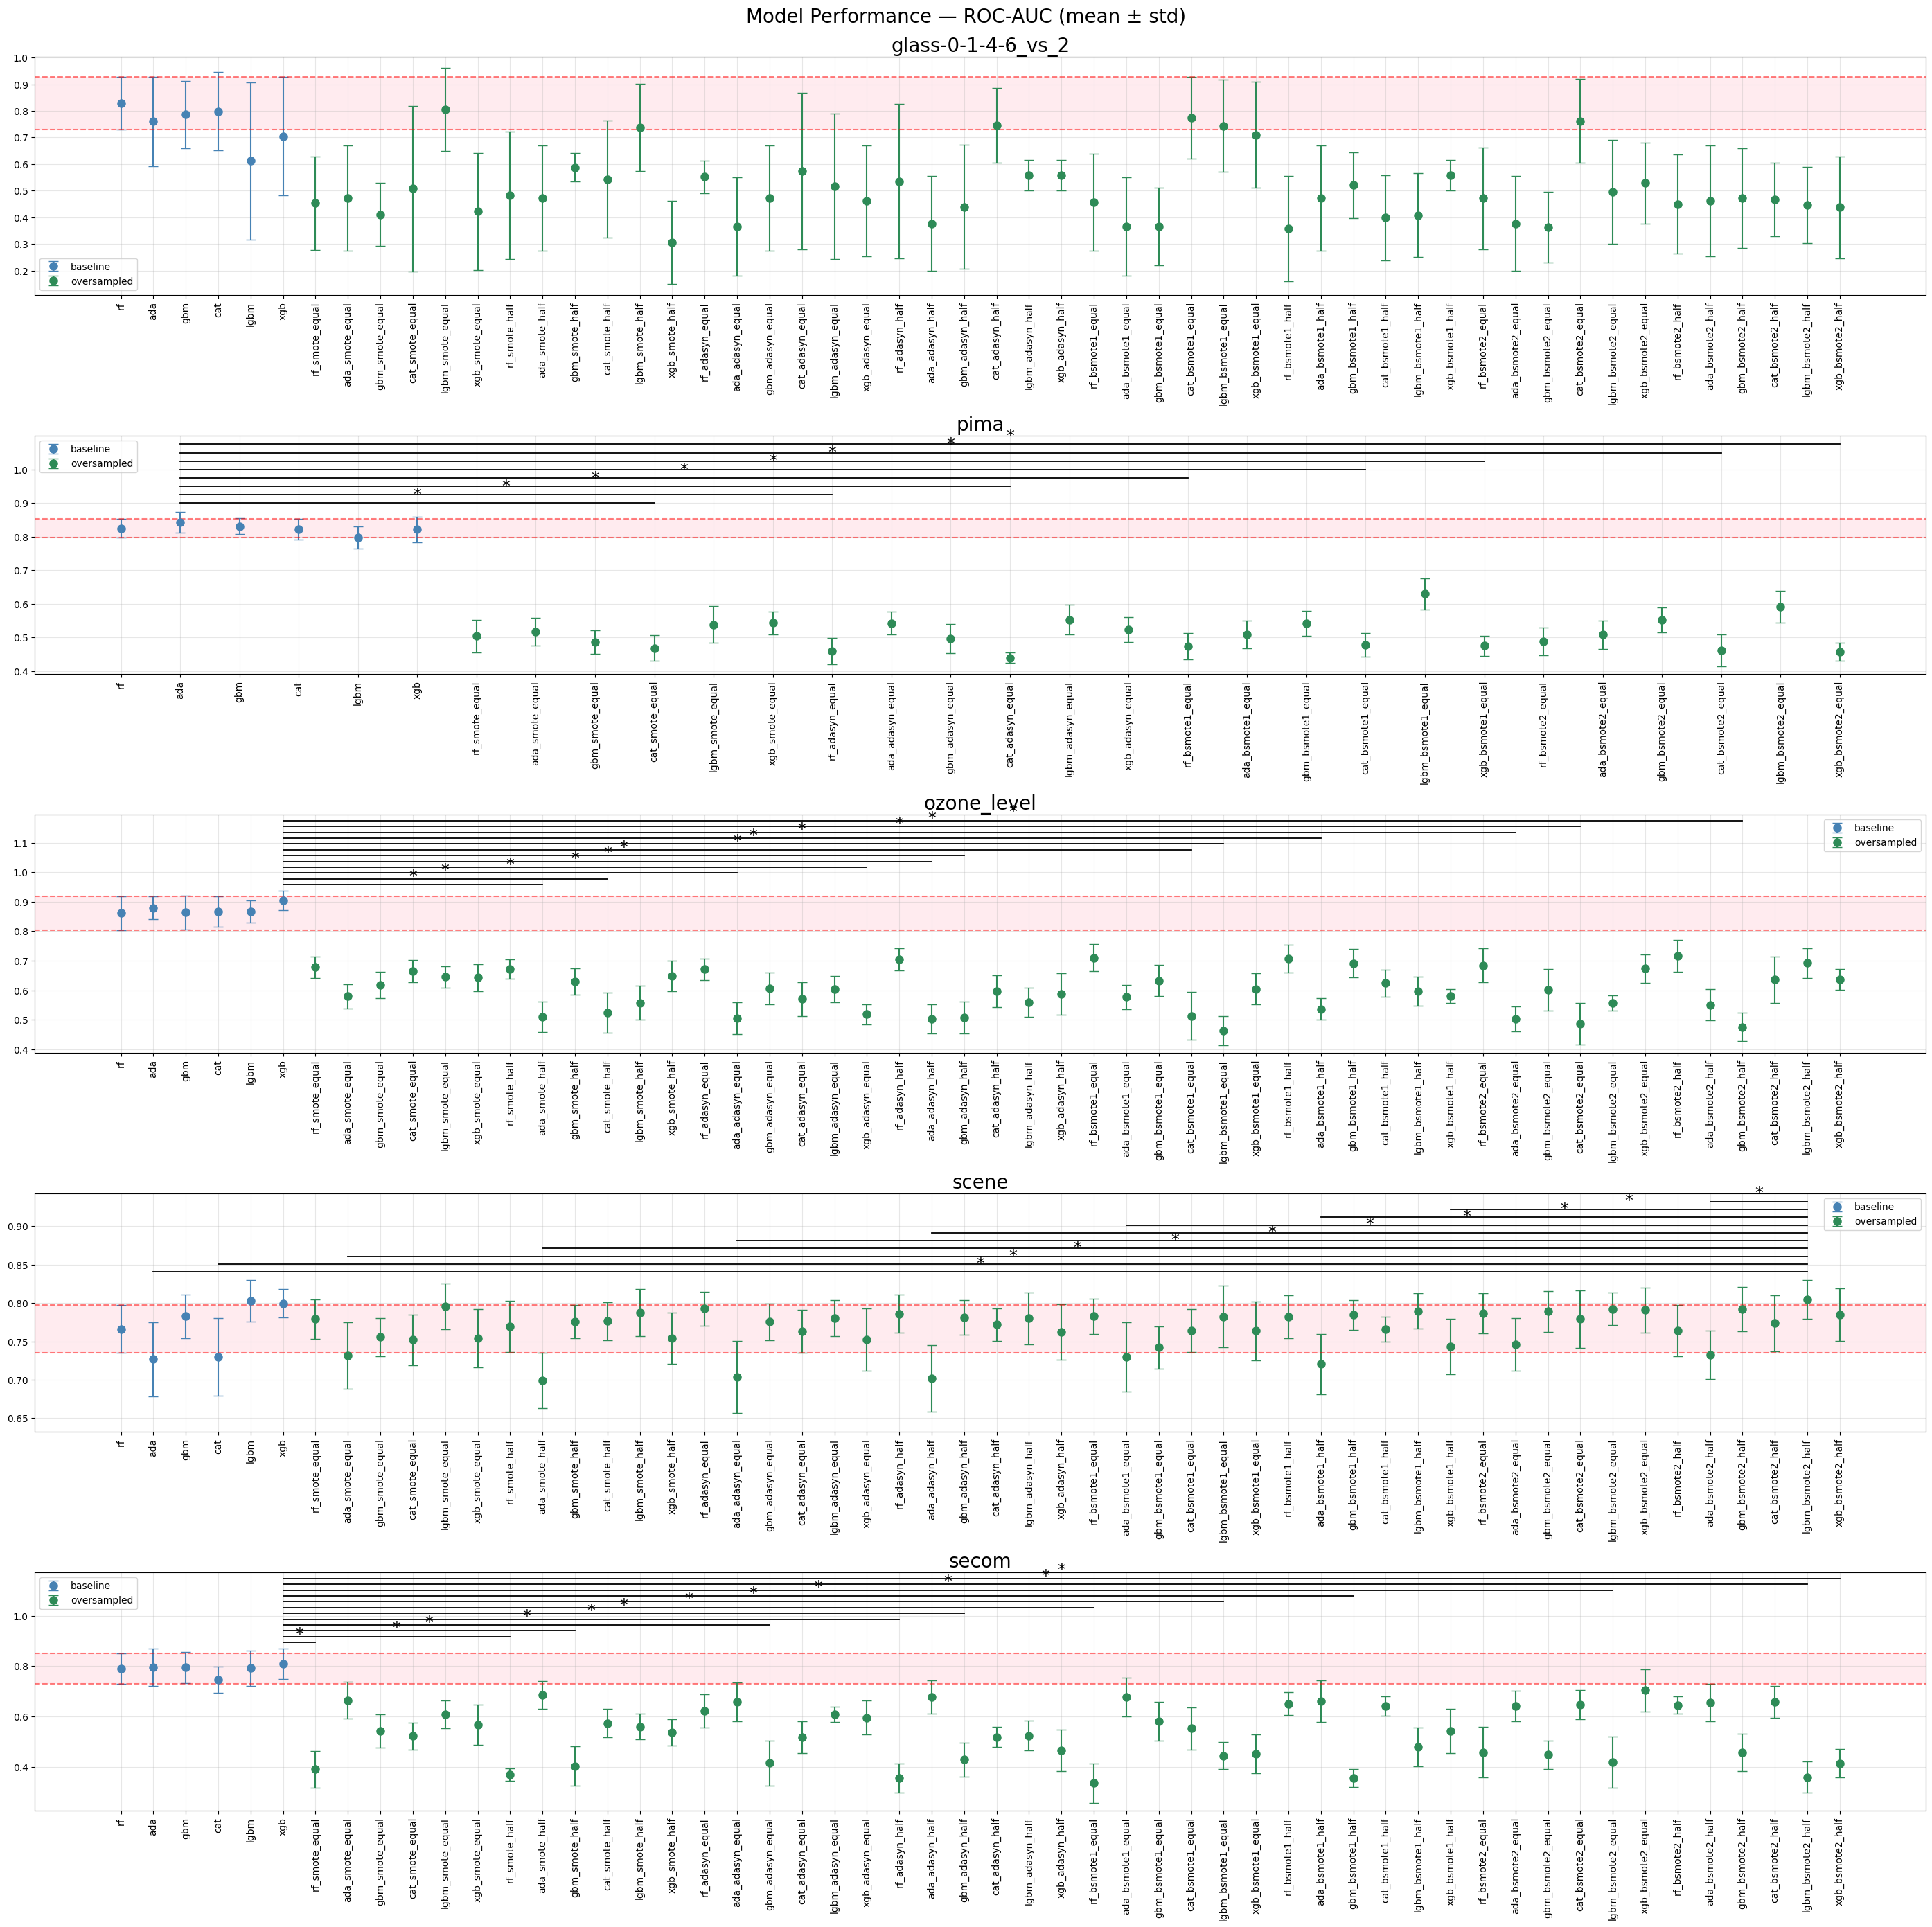

In [9]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["roc"]
    stds  = df["roc_std"]

    upper = df.loc[df.index[0], "roc"] + df.loc[df.index[0], "roc_std"]
    lower = df.loc[df.index[0], "roc"] - df.loc[df.index[0], "roc_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_roc:
        best_model = means.idxmin() if "roc" == "brier" else means.idxmax()
        posthoc = nemenyi_roc[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — ROC-AUC (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_rocauc_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC-AUC conclusion

The Friedman test is significant in **5 / 5 datasets**. A
baseline model (without any oversampling) is the best performer in **4 out of 5**
datasets — typically `xgb`, `ada`, or `rf`. The only exception is `scene`, where
`lgbm_bsmote2_half` ranks first. On `glass-0-1-4-6_vs_2`
no model is significantly worse than the best, meaning all 54 models are
statistically equivalent on ROC-AUC. Overall, SMOTE-based methods do not improve ROC-AUC
relative to training on the original class distribution.

## Average Precision Friedman test

In [10]:
friedman_rows = []
nemenyi_ap = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "ap")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_ap[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,134.591158,4.926056e-09
pima,114.682581,3.859633e-12
ozone_level,238.603232,2.236737e-25
scene,177.599596,2.331129e-15
secom,207.805657,3.342593e-20


## Plot Average Precision

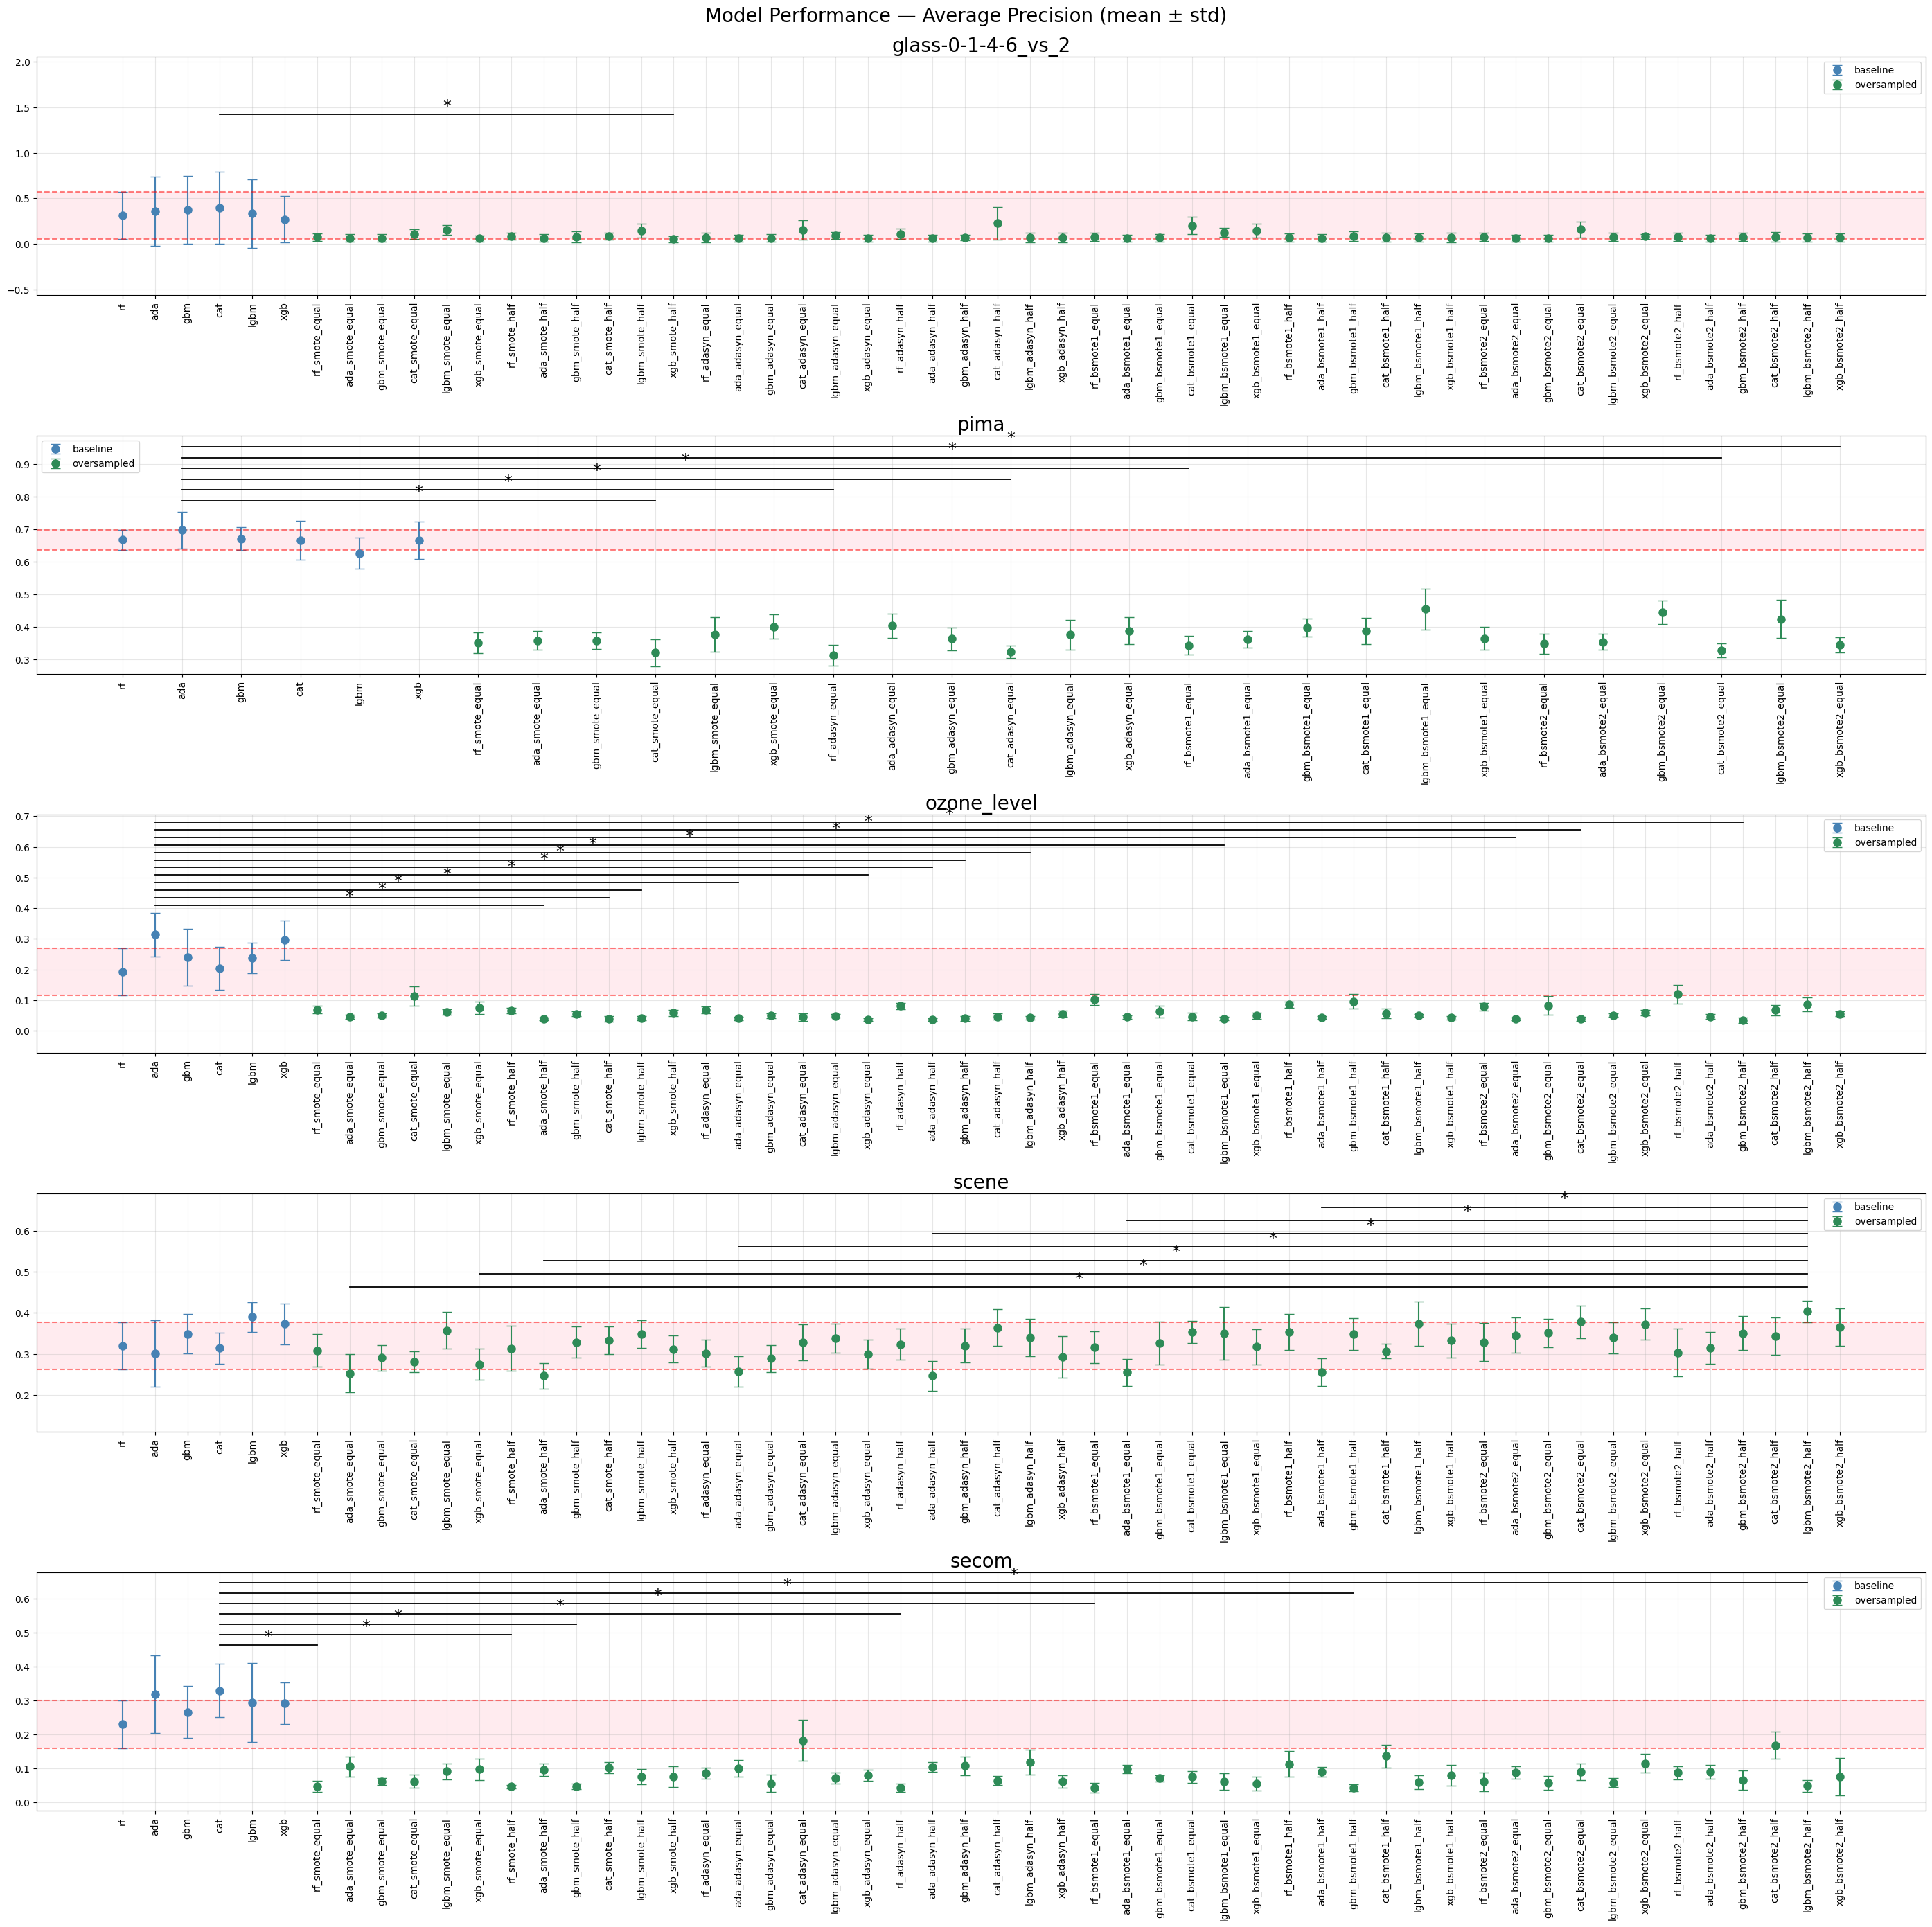

In [11]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["ap"]
    stds  = df["ap_std"]

    upper = df.loc[df.index[0], "ap"] + df.loc[df.index[0], "ap_std"]
    lower = df.loc[df.index[0], "ap"] - df.loc[df.index[0], "ap_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_ap:
        best_model = means.idxmin() if "ap" == "brier" else means.idxmax()
        posthoc = nemenyi_ap[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Average Precision (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_ap_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### Average Precision conclusion

The Friedman test is significant in **5 / 5 datasets**. The baseline model is best in
4 out of 5 datasets, with `scene` again being the exception (`lgbm_bsmote2_half`).
The Nemenyi test finds 1–12 models significantly worse than the best. The pattern
mirrors ROC-AUC: SMOTE/ADASYN/BorderlineSMOTE variants do not improve precision-recall
performance over the baselines, and on several datasets they are significantly
worse.

## Recall Friedman test

In [12]:
friedman_rows = []
nemenyi_recall = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "recall")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_recall[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,53.000000,4.741626e-01
pima,102.860395,3.392827e-10
ozone_level,94.830963,3.660508e-04
scene,68.120907,7.899747e-02
secom,95.334982,3.239823e-04


## Plot Recall

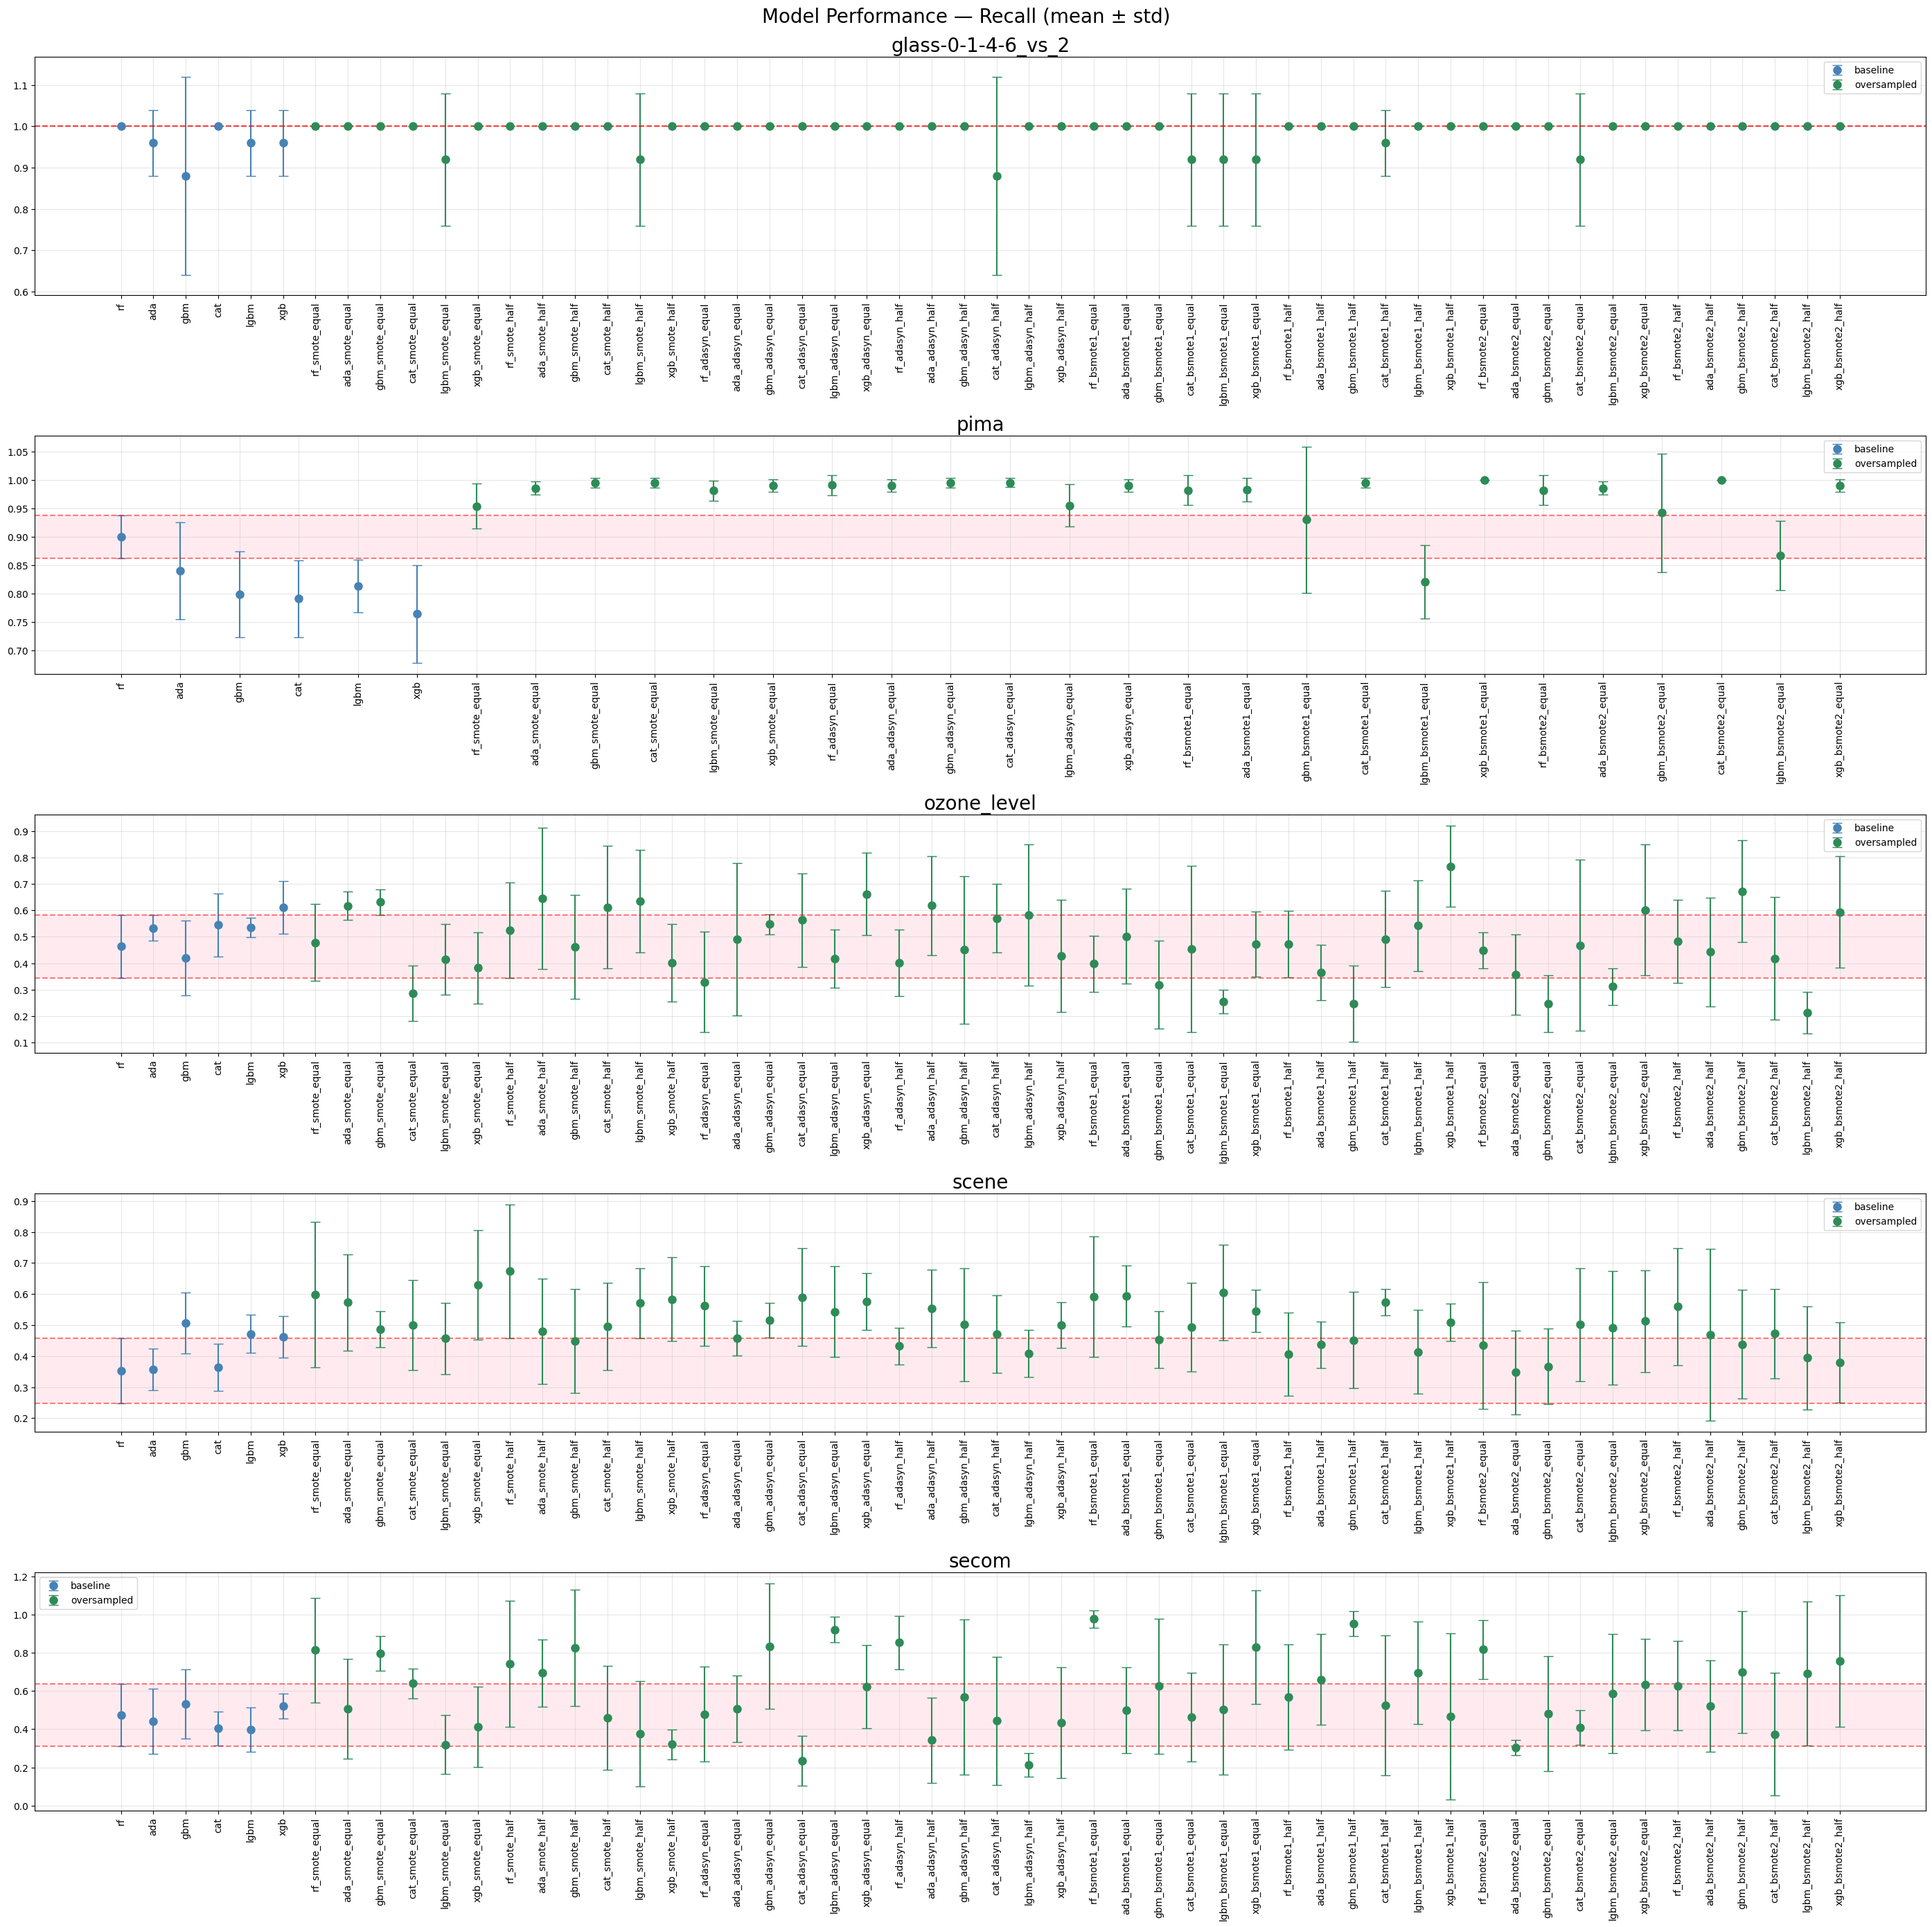

In [13]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["recall"]
    stds  = df["recall_std"]

    upper = df.loc[df.index[0], "recall"] + df.loc[df.index[0], "recall_std"]
    lower = df.loc[df.index[0], "recall"] - df.loc[df.index[0], "recall_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_recall:
        best_model = means.idxmin() if "recall" == "brier" else means.idxmax()
        posthoc = nemenyi_recall[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Recall (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_recall_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### Recall conclusion

The Friedman test is significant in **3 / 5 datasets**. In all three significant
cases the best model is a SMOTE/ADASYN variant, reflecting that synthetic oversampling
shifts decision boundaries towards higher recall. However, as the AP and F1 results
show, this recall gain does not translate into an overall improvement in
precision-recall trade-off.

## F1-score Friedman test

In [14]:
friedman_rows = []
nemenyi_f1 = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "f1")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_f1[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,143.106085,3.223821e-10
pima,119.881119,5.154183e-13
ozone_level,227.340180,1.843245e-23
scene,152.134577,1.629855e-11
secom,195.743951,3.087005e-18


## Plot F1-score

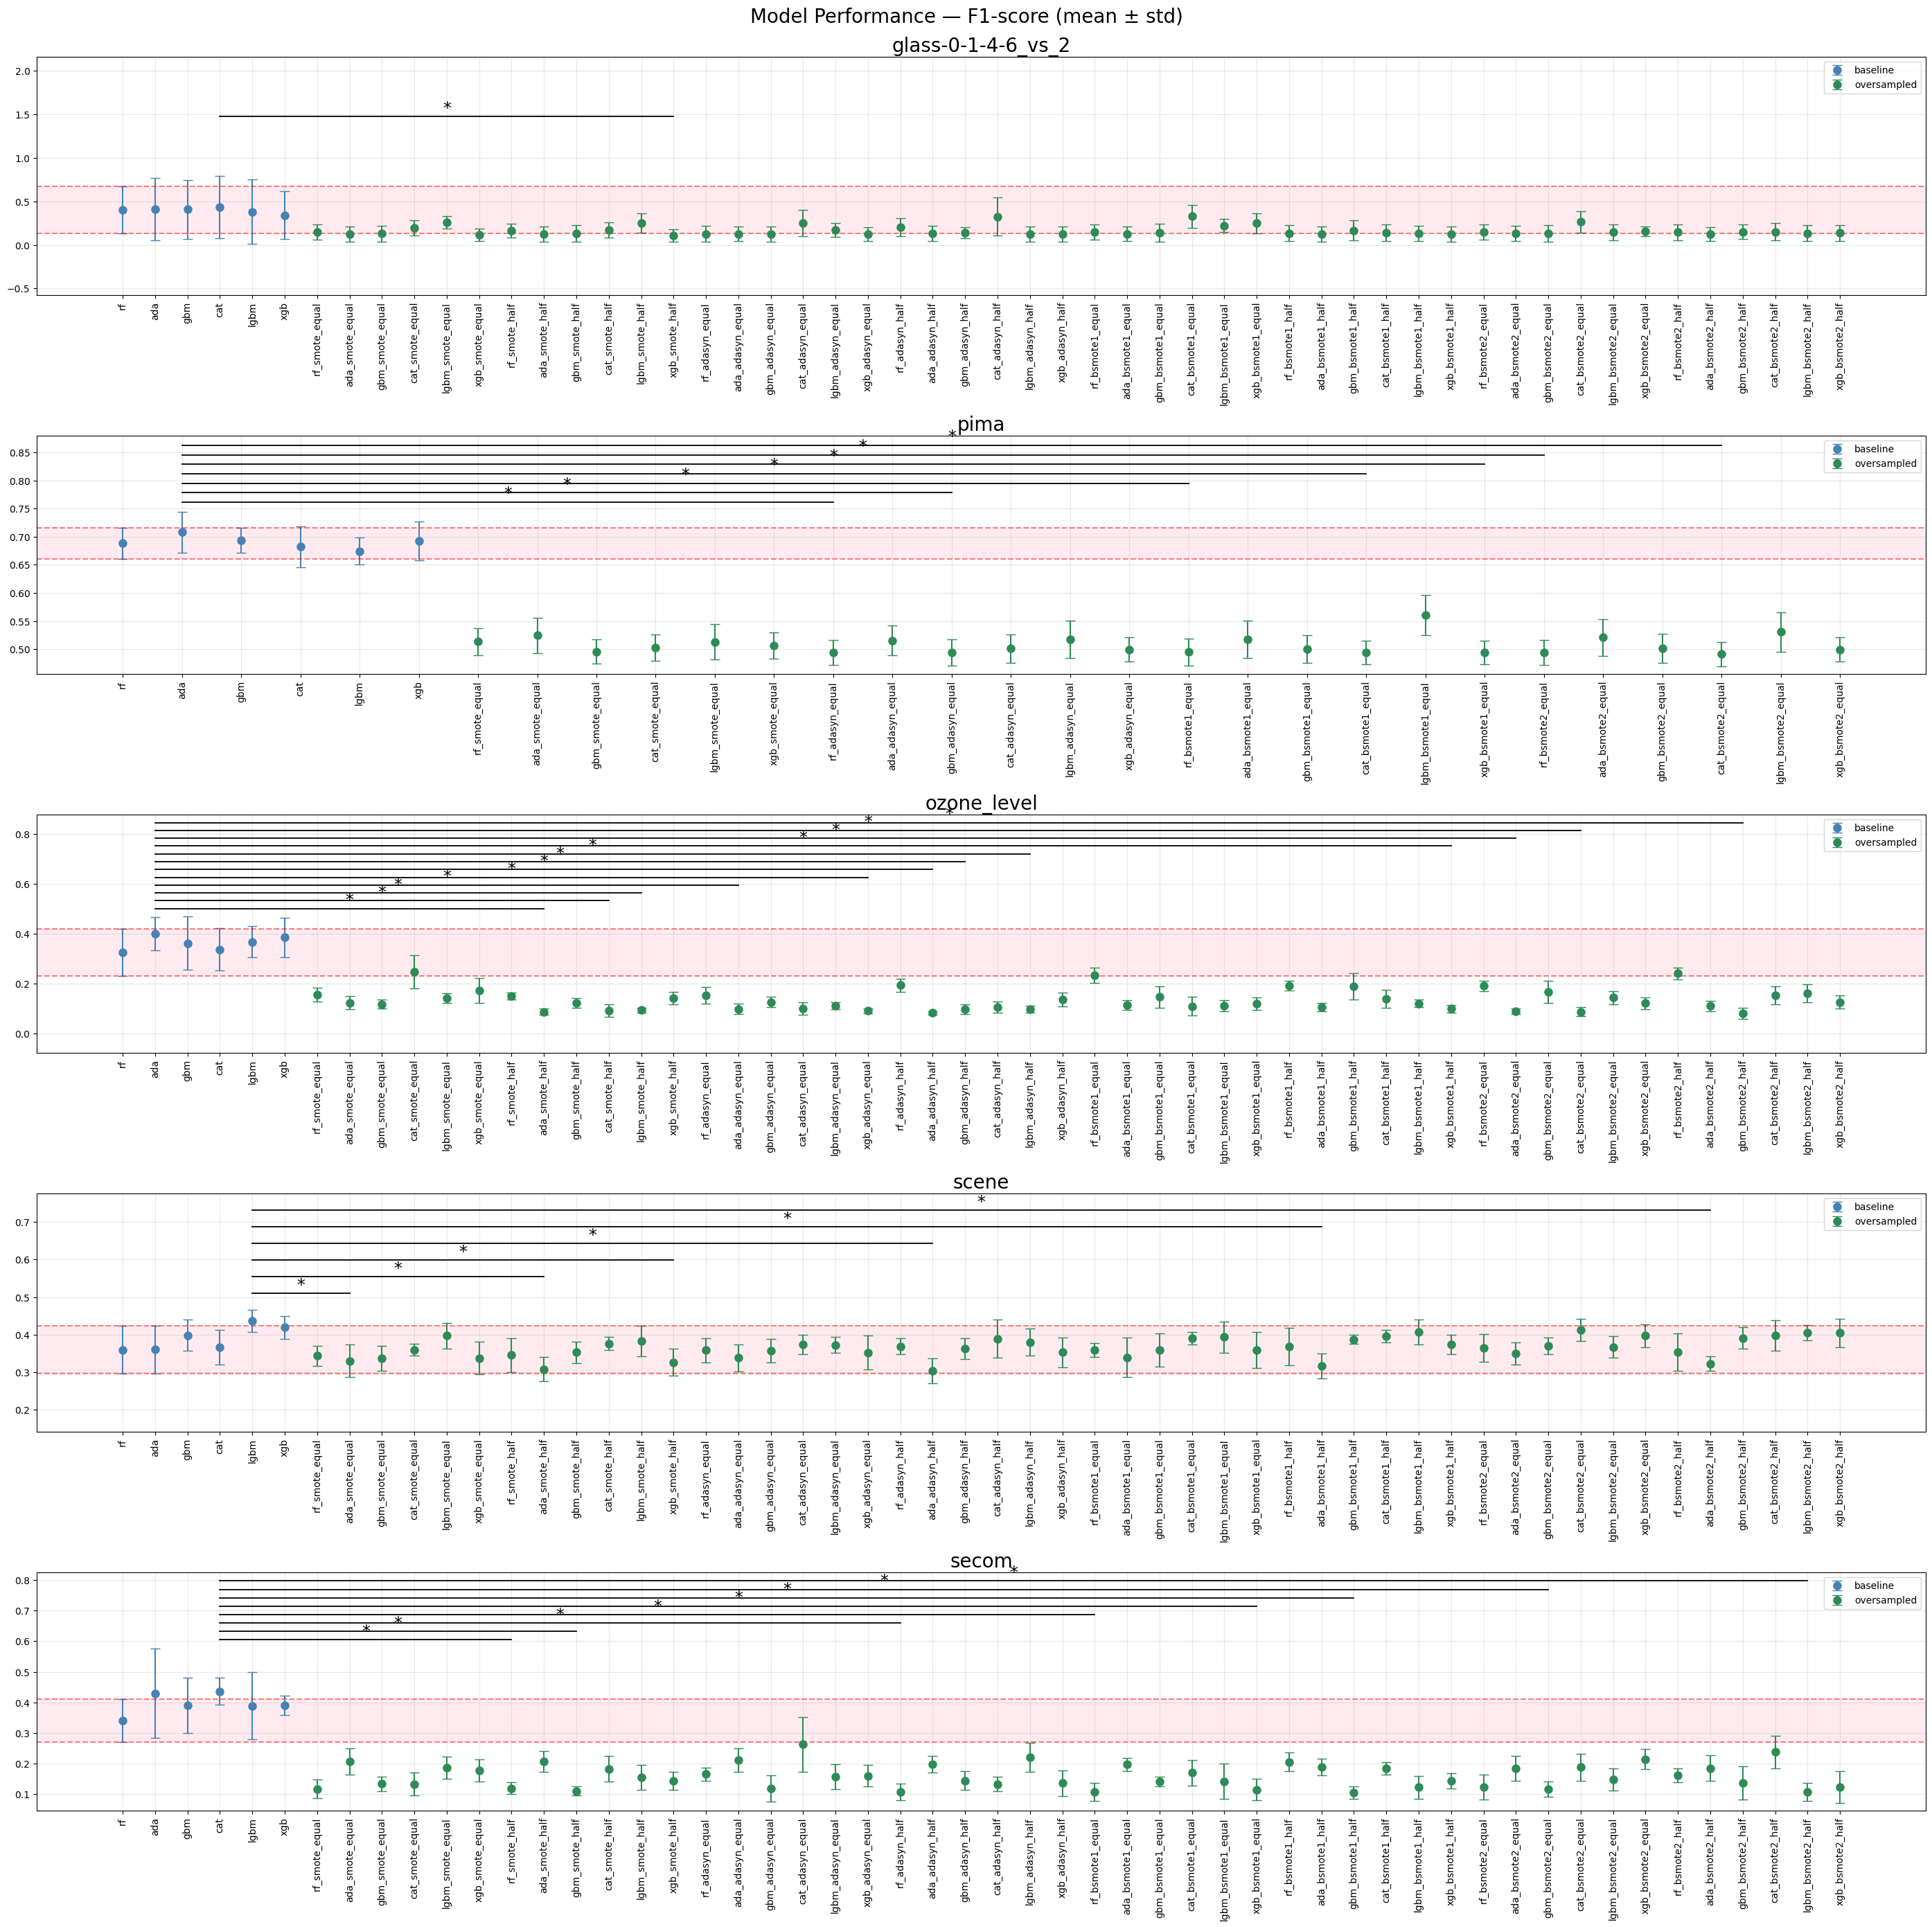

In [15]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["f1_score"]
    stds  = df["f1_std"]

    upper = df.loc[df.index[0], "f1_score"] + df.loc[df.index[0], "f1_std"]
    lower = df.loc[df.index[0], "f1_score"] - df.loc[df.index[0], "f1_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_f1:
        best_model = means.idxmin() if "f1_score" == "brier" else means.idxmax()
        posthoc = nemenyi_f1[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — F1-score (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_f1_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### F1-score conclusion

The Friedman test is significant in **5 / 5 datasets** and a **baseline model is
the best performer in all 5 datasets**. The Nemenyi test finds 1–12 models
significantly worse than the best. This is the clearest finding in the notebook:
SMOTE-based oversampling consistently degrades F1-score relative to the baseline,
because the precision drop caused by the shifted decision boundary outweighs the
recall gain.

## MCC Friedman test

In [16]:
friedman_rows = []
nemenyi_mcc = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "mcc")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_mcc[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,143.052338,3.280702e-10
pima,104.171819,2.080888e-10
ozone_level,227.749975,1.571528e-23
scene,150.012806,3.313485e-11
secom,204.142310,1.333700e-19


## Plot MCC

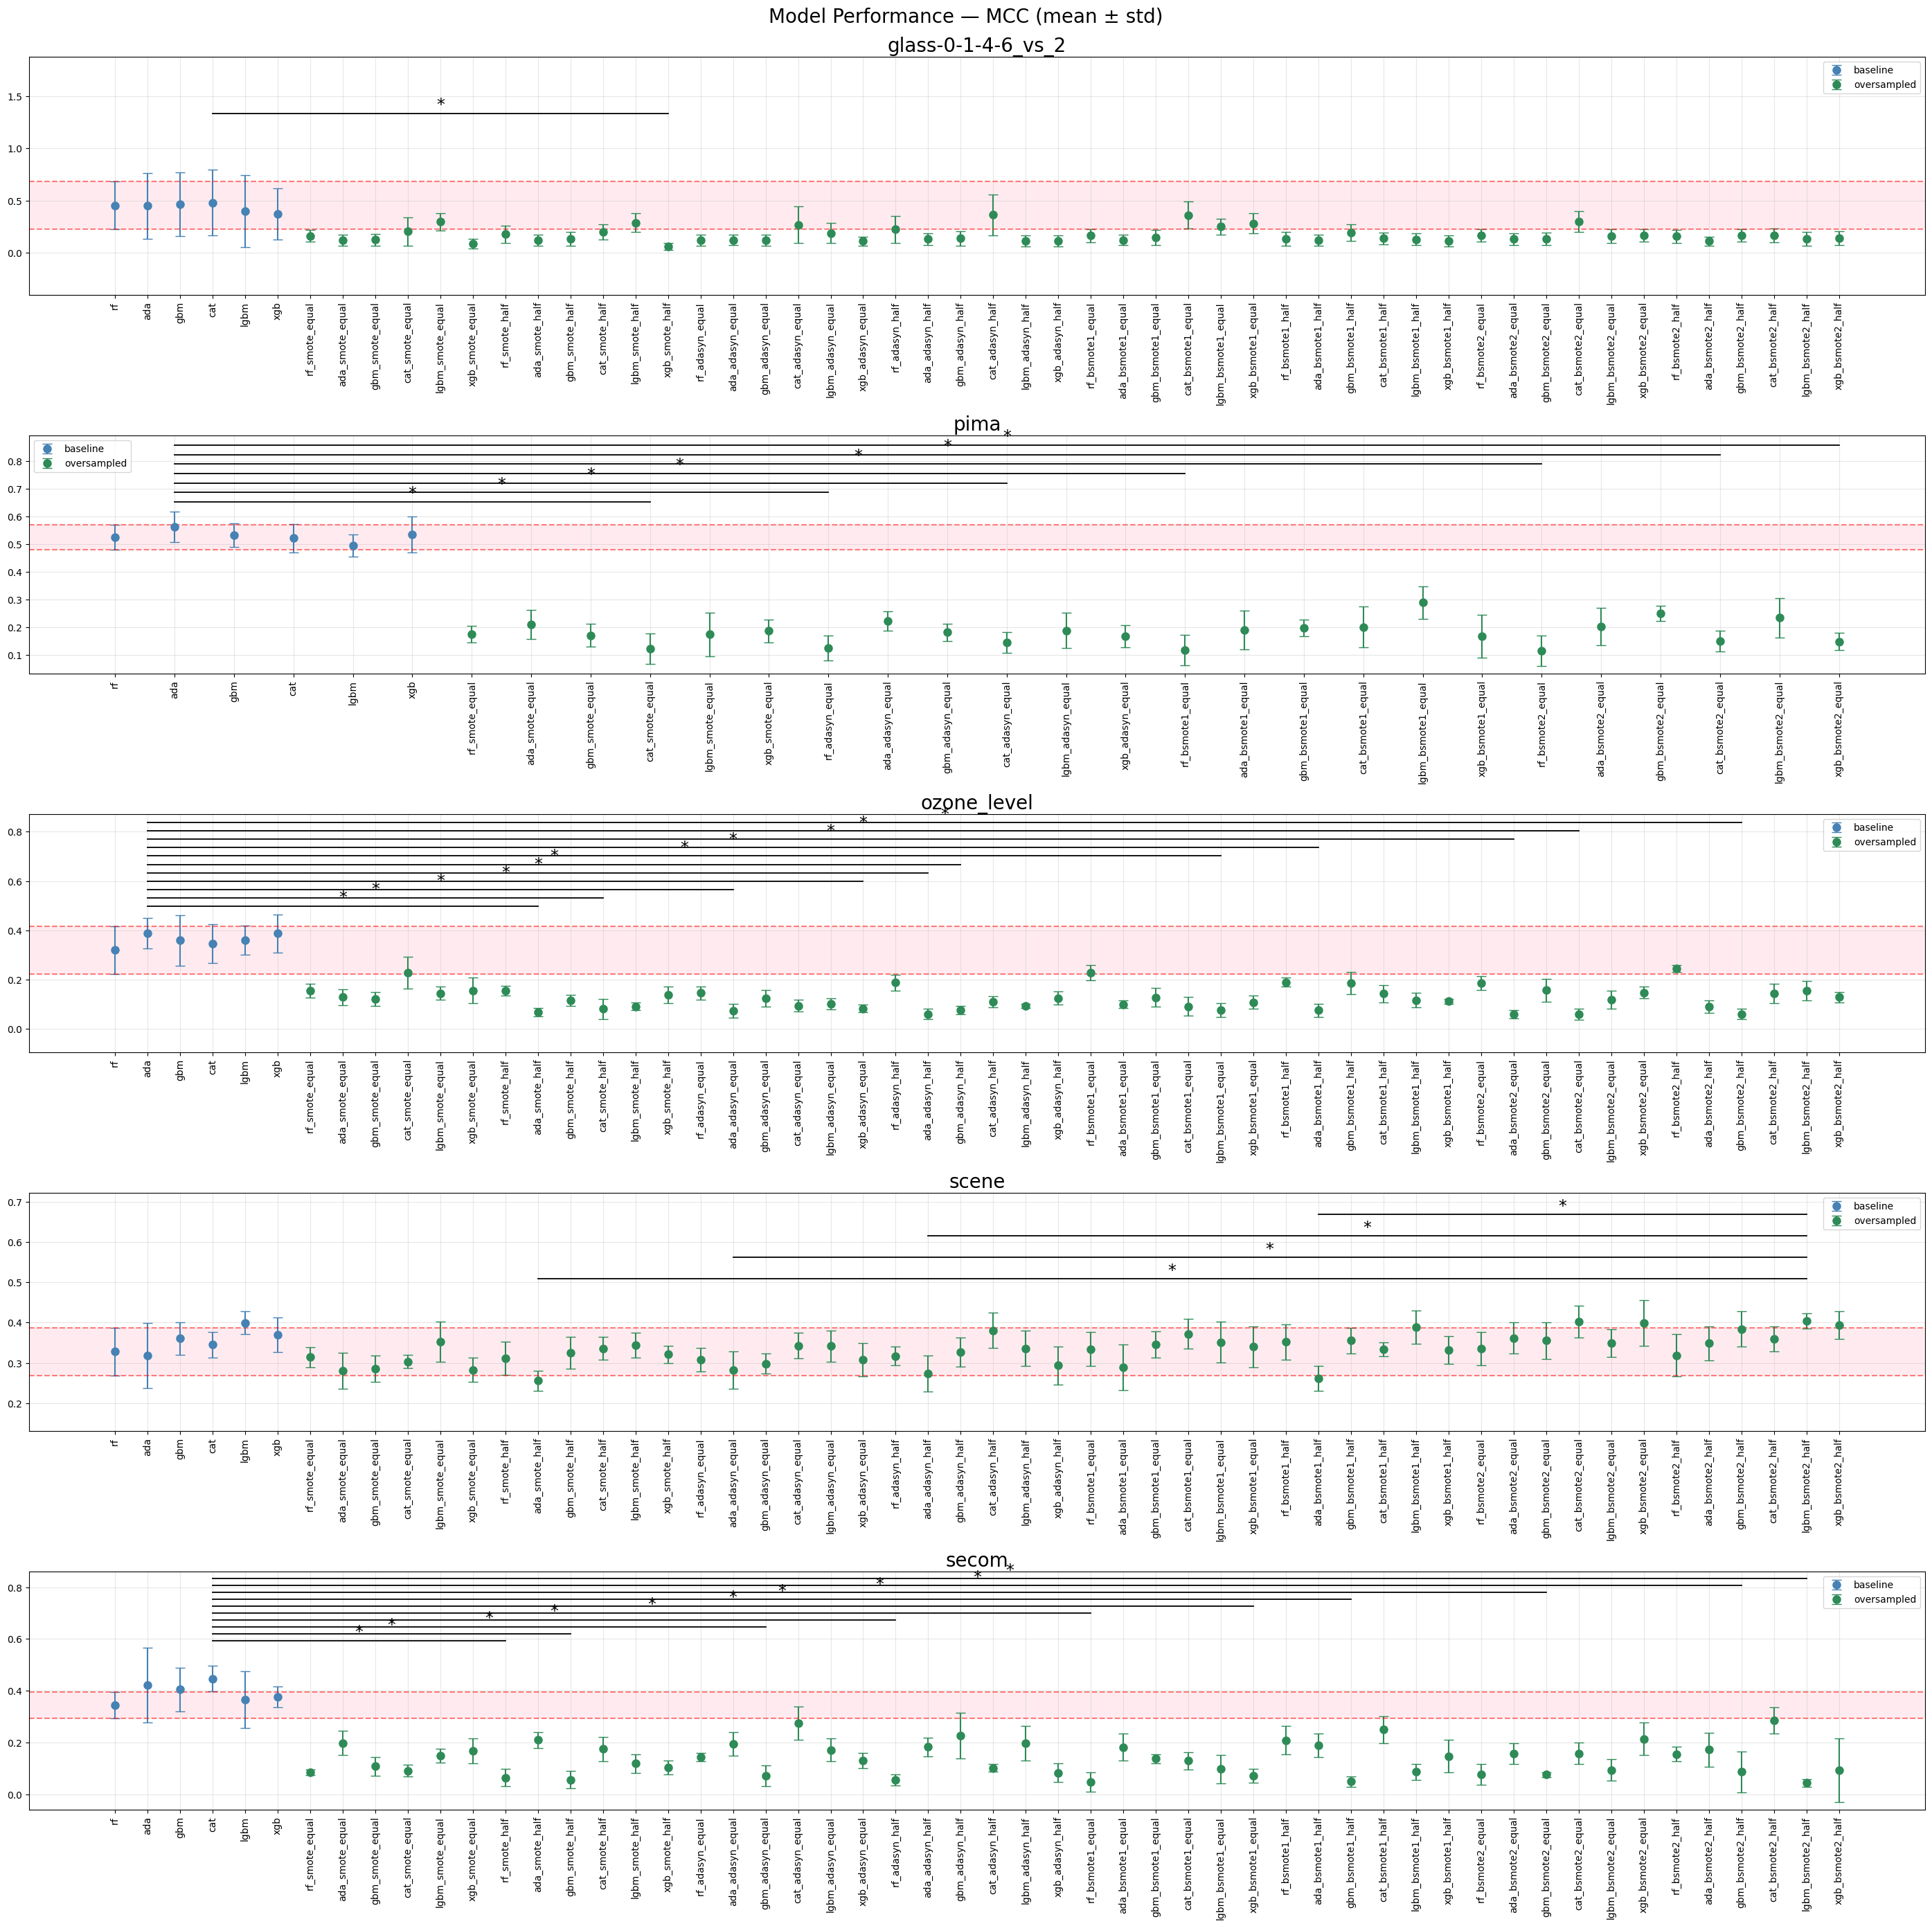

In [17]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["mcc"]
    stds  = df["mcc_std"]

    upper = df.loc[df.index[0], "mcc"] + df.loc[df.index[0], "mcc_std"]
    lower = df.loc[df.index[0], "mcc"] - df.loc[df.index[0], "mcc_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_mcc:
        best_model = means.idxmin() if "mcc" == "brier" else means.idxmax()
        posthoc = nemenyi_mcc[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — MCC (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_mcc_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### MCC conclusion

The Friedman test is significant in **5 / 5 datasets**. The baseline is best in 4
out of 5 datasets. The Nemenyi test finds 1–11 models significantly worse than the
best. MCC confirms the F1 finding: SMOTE-based variants do not improve over the
baselines on a balanced metric, and on harder datasets (`ozone_level`, `secom`) many
SMOTE variants are significantly worse.

## Balanced Accuracy Friedman test

In [18]:
friedman_rows = []
nemenyi_ba = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "ba")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_ba[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,142.850055,3.503816e-10
pima,98.759446,1.543737e-09
ozone_level,225.162319,4.296153e-23
scene,198.994457,9.197817e-19
secom,212.860281,4.891022e-21


## Plot Balanced Accuracy

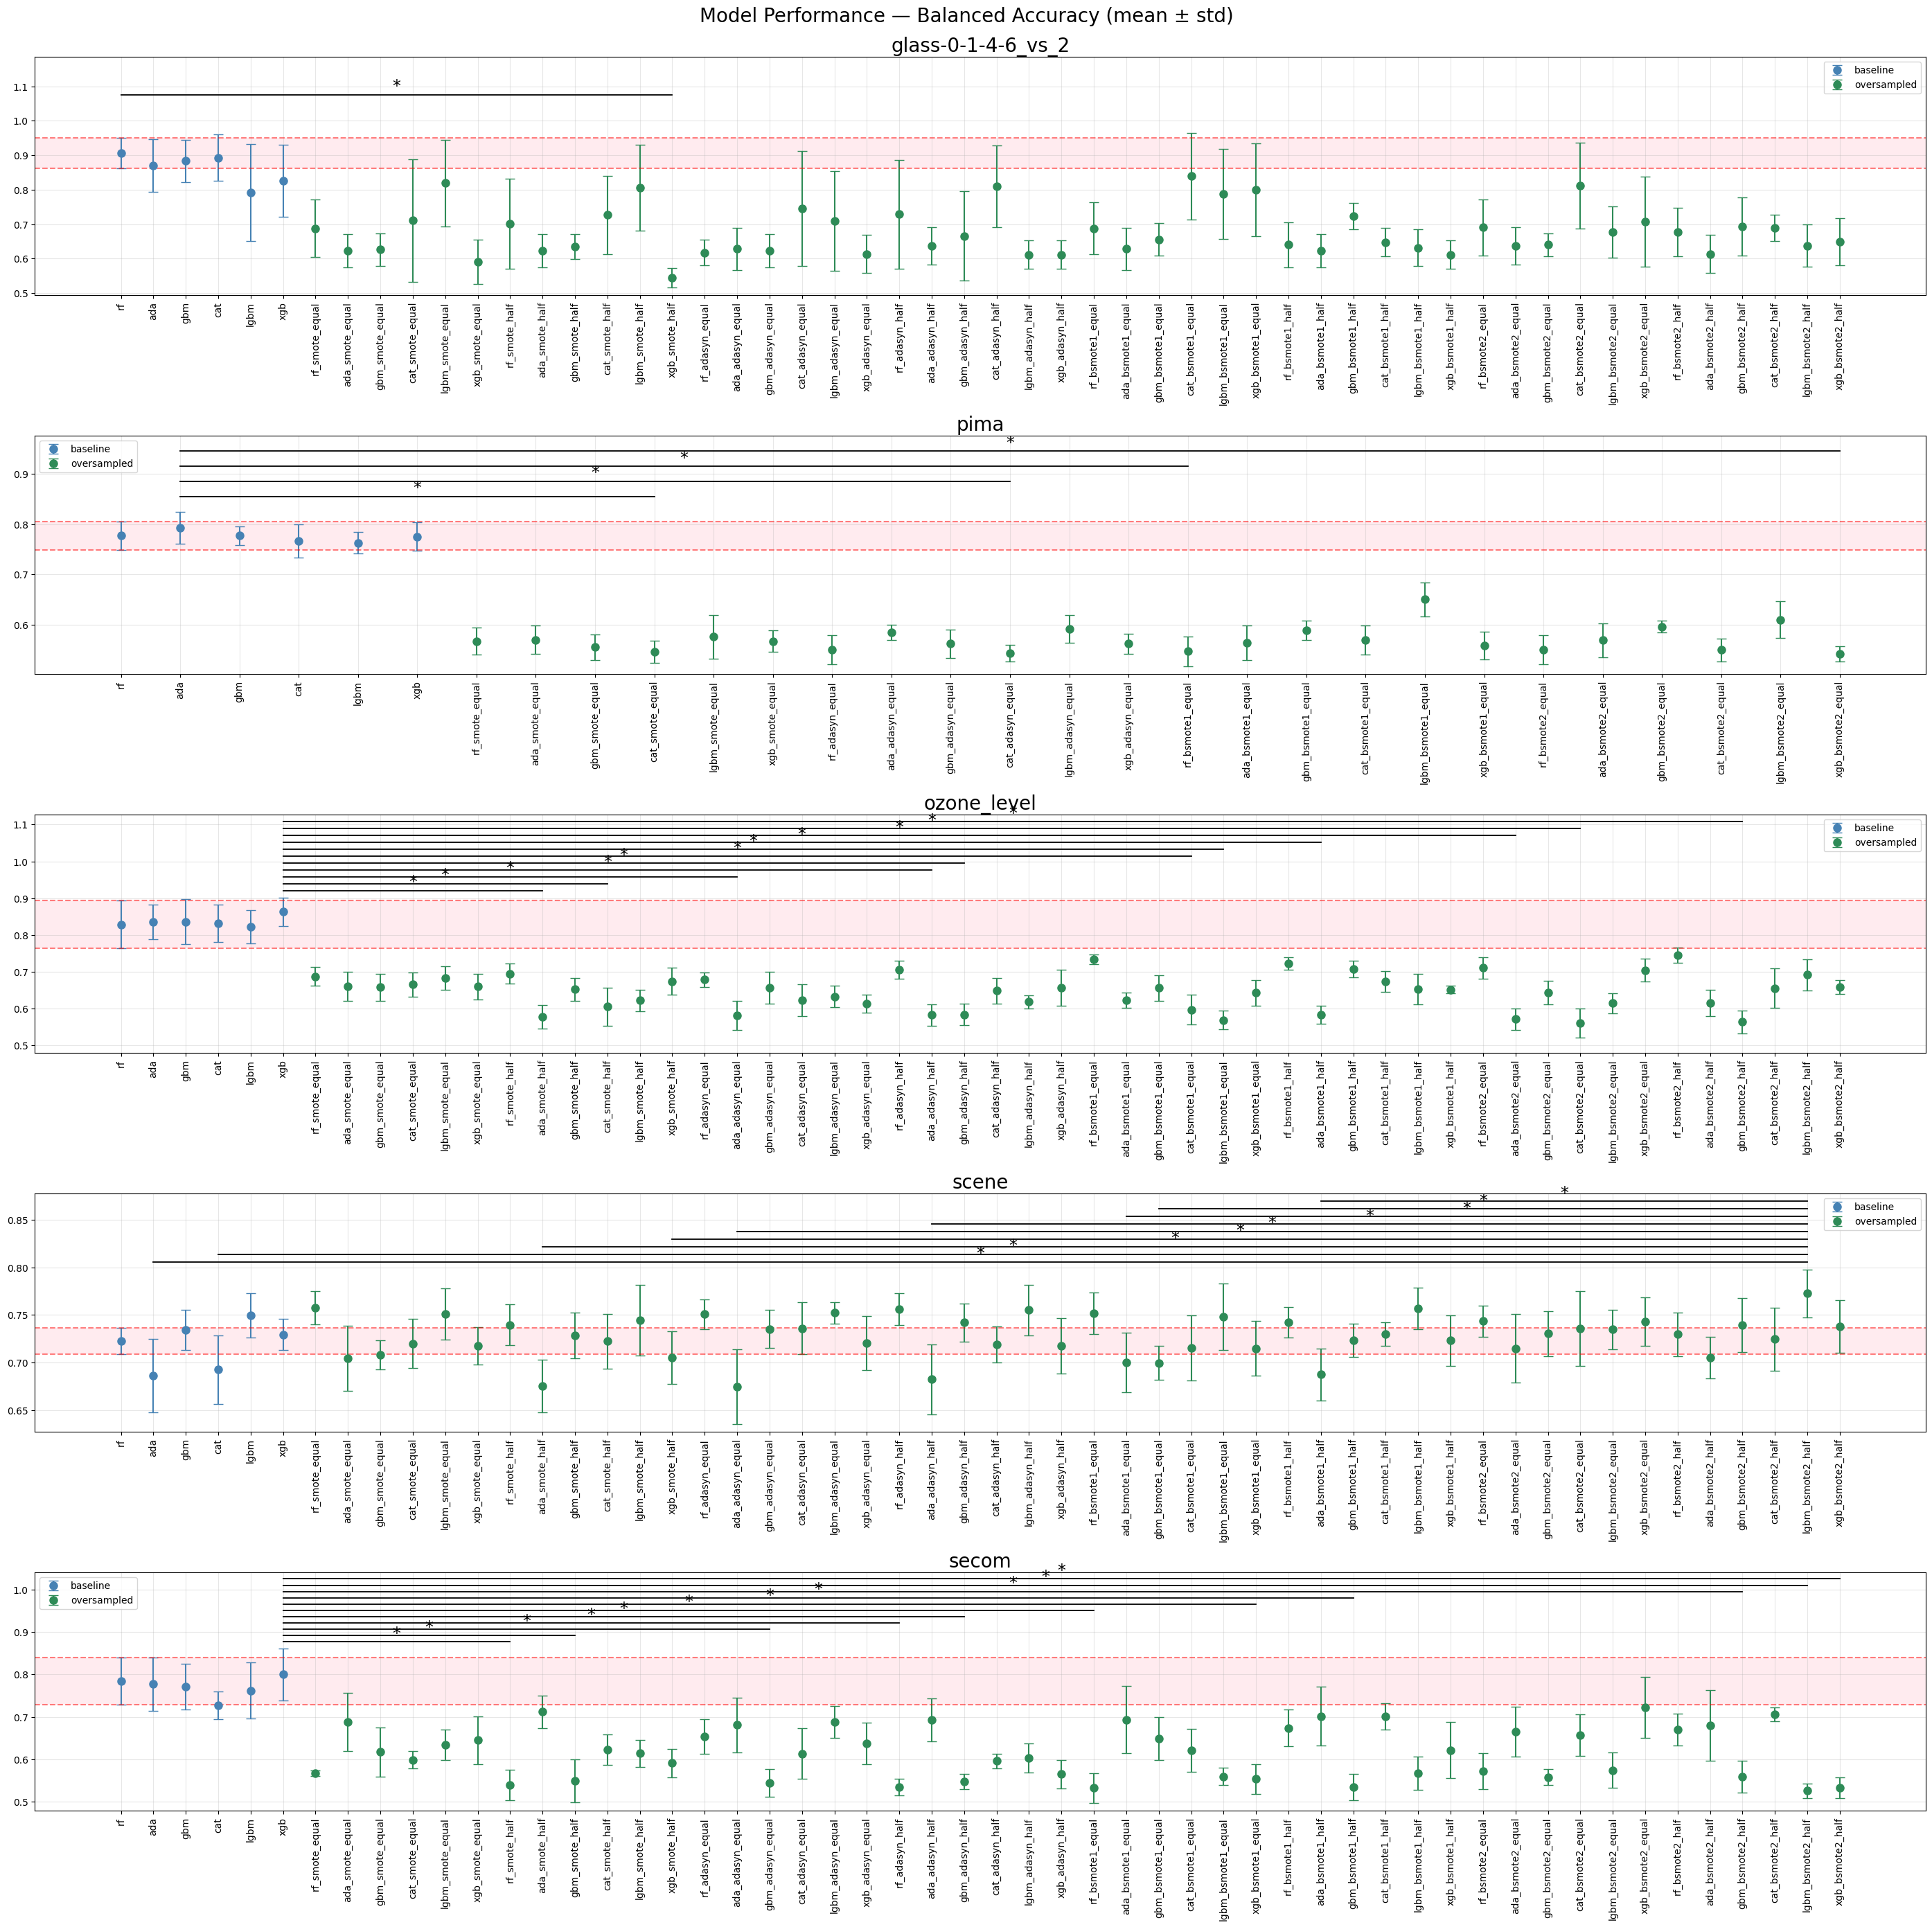

In [19]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["ba"]
    stds  = df["ba_std"]

    upper = df.loc[df.index[0], "ba"] + df.loc[df.index[0], "ba_std"]
    lower = df.loc[df.index[0], "ba"] - df.loc[df.index[0], "ba_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_ba:
        best_model = means.idxmin() if "ba" == "brier" else means.idxmax()
        posthoc = nemenyi_ba[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Balanced Accuracy (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_ba_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### Balanced Accuracy conclusion

The Friedman test is significant in **5 / 5 datasets**. The baseline is best in 4
out of 5 datasets, with `lgbm_bsmote2_half` winning on `scene`. The Nemenyi test
finds 1–11 models significantly worse than the best. The pattern aligns with MCC: no
consistent benefit from synthetic oversampling, and multiple SMOTE variants perform
significantly worse than the best baseline on balanced accuracy.

## Brier Score Friedman test

In [20]:
friedman_rows = []
nemenyi_brier = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "brier")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_brier[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,186.037576,1.100974e-16
pima,144.540645,2.716840e-17
ozone_level,251.076768,1.583656e-27
scene,237.843636,3.017272e-25
secom,255.206061,3.033228e-28


## Plot Brier Score

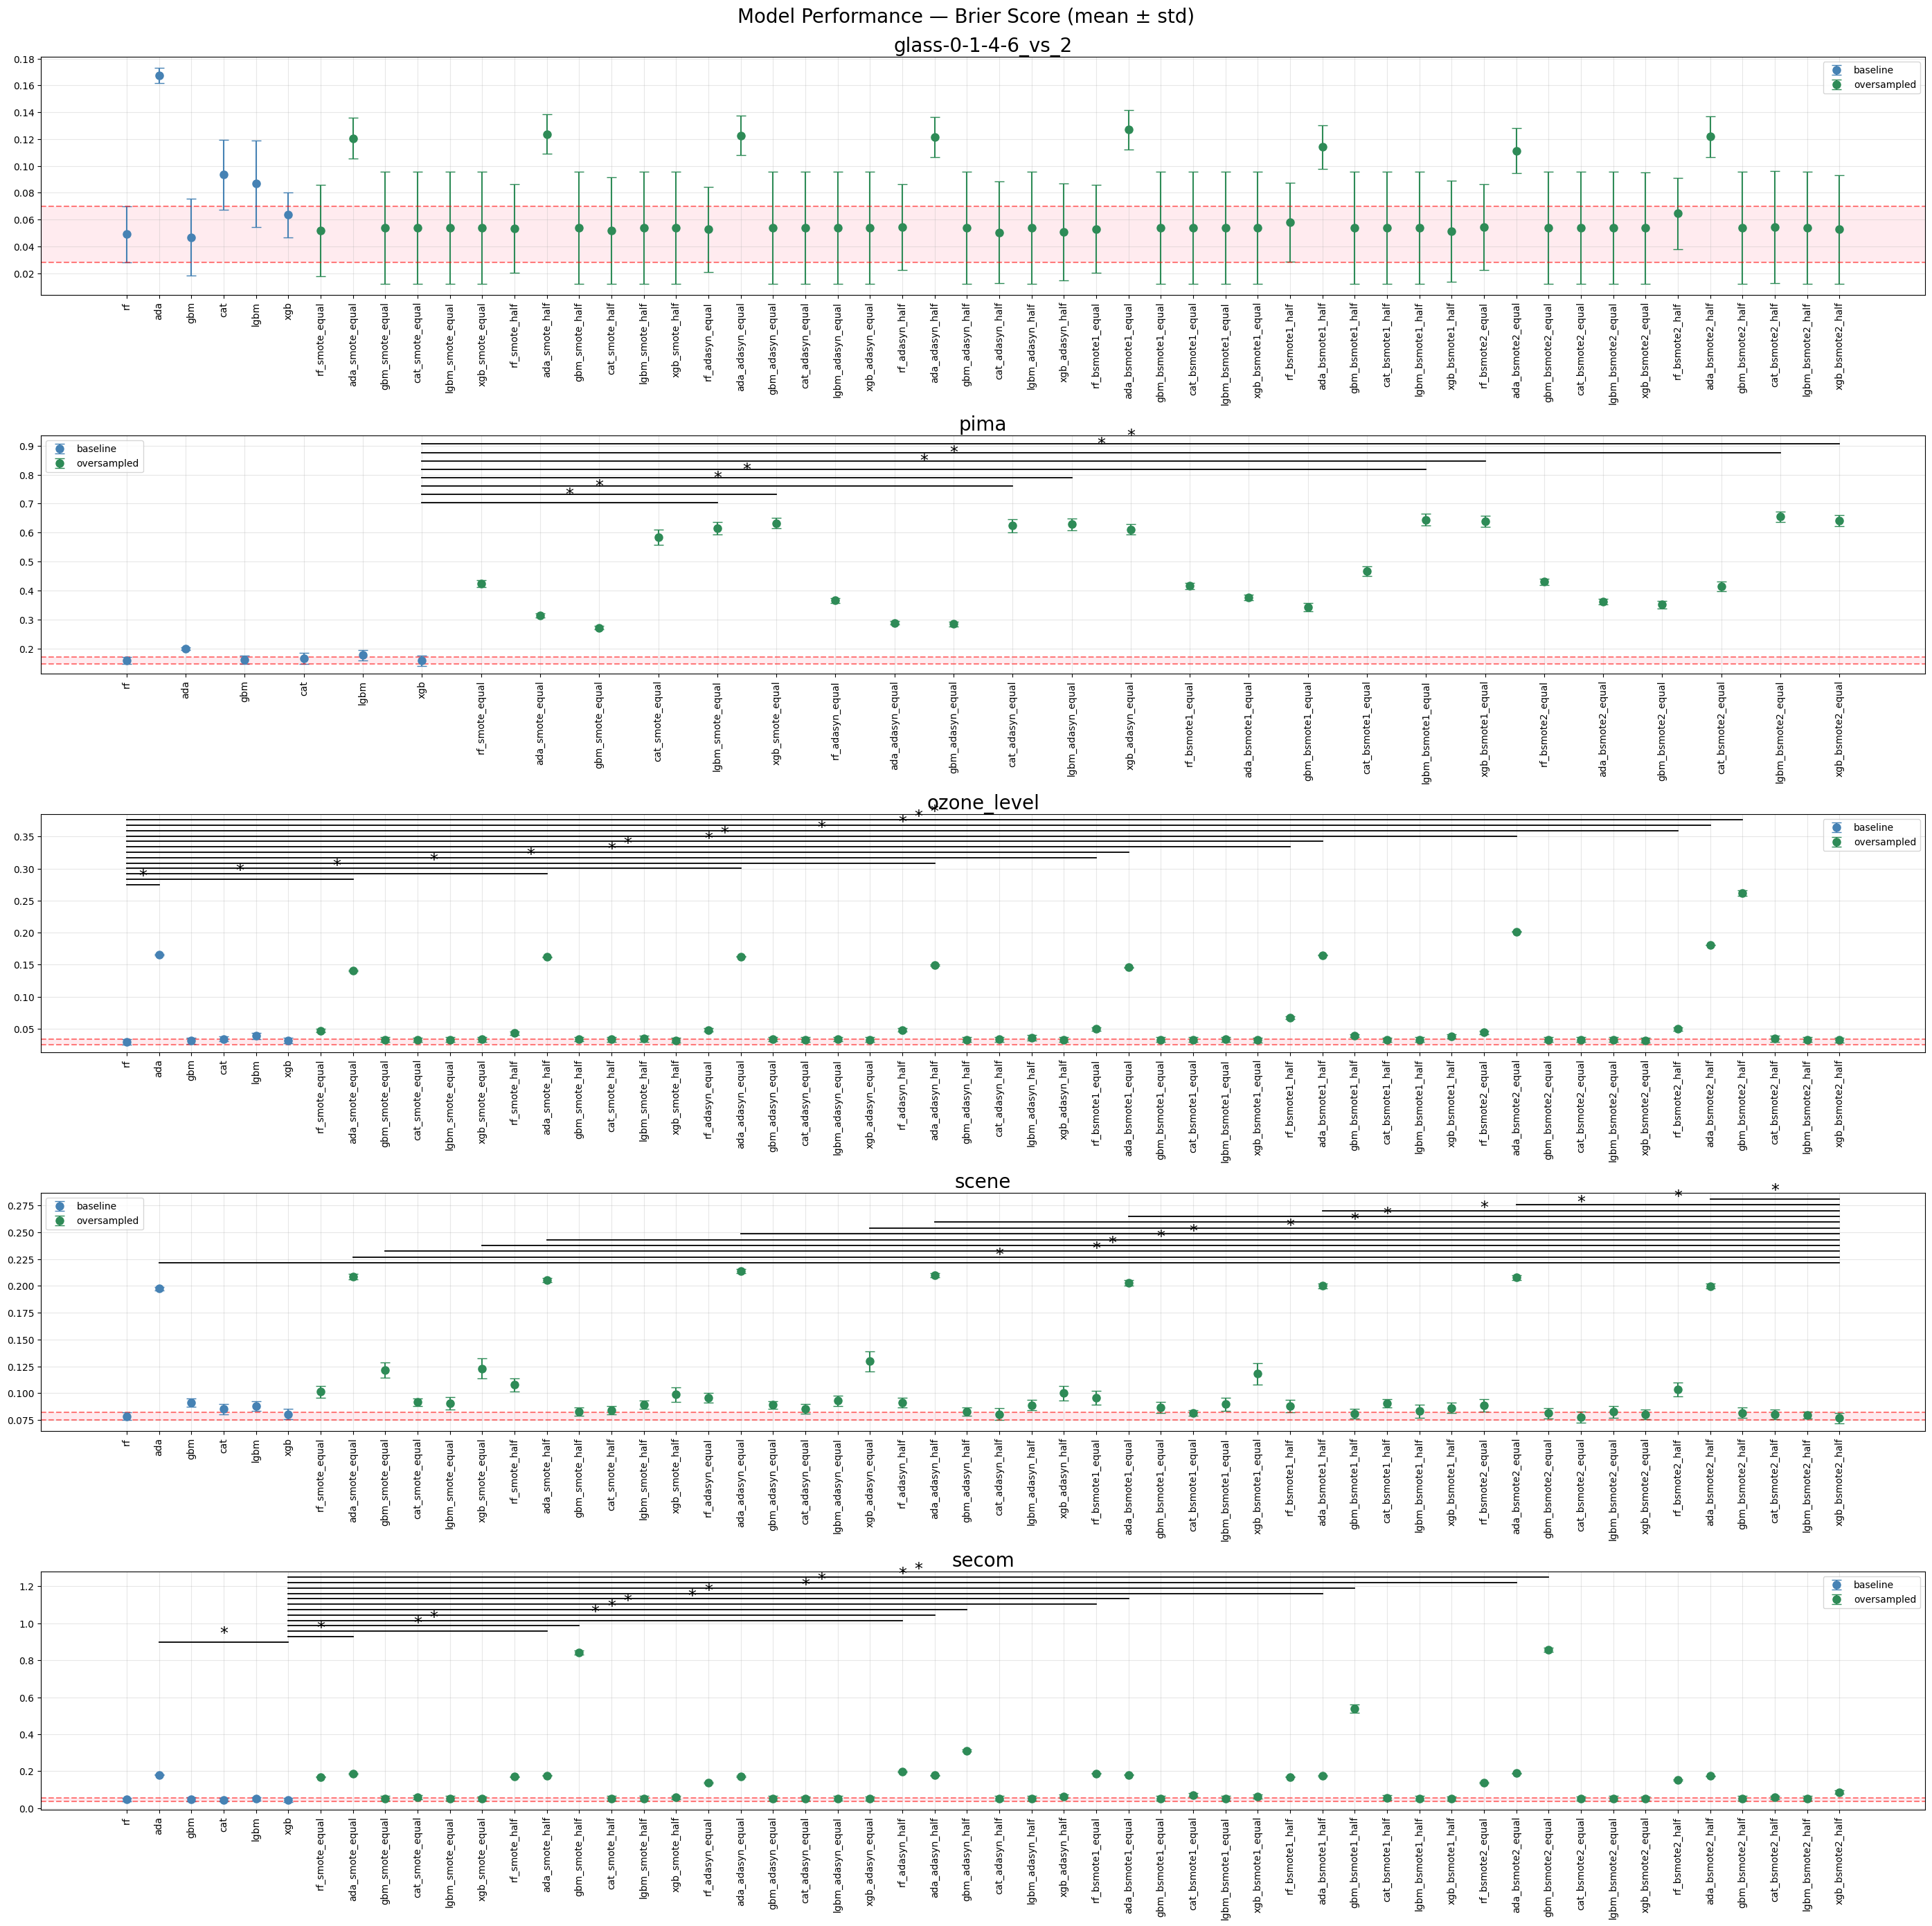

In [21]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["brier"]
    stds  = df["brier_std"]

    upper = df.loc[df.index[0], "brier"] + df.loc[df.index[0], "brier_std"]
    lower = df.loc[df.index[0], "brier"] - df.loc[df.index[0], "brier_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_brier:
        best_model = means.idxmin() if "brier" == "brier" else means.idxmax()
        posthoc = nemenyi_brier[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='seagreen', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Brier Score (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_brier_smote.png', dpi=300, bbox_inches='tight')
plt.show()

### Brier Score conclusion

The Friedman test is significant in **5 / 5 datasets**. The baseline model (`rf`,
`xgb`, or `gbm`) is best in 4 out of 5 datasets. The Nemenyi test finds the most
pairwise significant differences here (0–13 models per dataset), with `glass` being
the exception where no model is significantly better than any other. Synthetic
oversampling generally degrades probability calibration: generating new synthetic
points near the decision boundary shifts the predicted probability distribution in a
way that increases Brier score for most variants.

## Best SMOTE variant per model and dataset

In [22]:
best_performance_summary(scores_dict, datasets, metric='roc',  metric_std='roc_std',  factor=3)
best_performance_summary(scores_dict, datasets, metric='ap',   metric_std='ap_std',   factor=3)
best_performance_summary(scores_dict, datasets, metric='ba',   metric_std='ba_std',   factor=3)

,dataset,model,ba,ba_std,best_csl_variant,best_csl_ba,best_csl_ba_std,ba_diff
0,glass-0-1-4-6_vs_2,rf,0.906518,0.044438,rf_adasyn_half,0.728839,0.158095,-0.177679
1,glass-0-1-4-6_vs_2,ada,0.870139,0.077193,ada_adasyn_half,0.637143,0.054606,-0.232996
2,glass-0-1-4-6_vs_2,gbm,0.883333,0.061237,gbm_bsmote1_half,0.723492,0.038373,-0.159841
3,glass-0-1-4-6_vs_2,cat,0.893056,0.067985,cat_bsmote1_equal,0.839692,0.125659,-0.053363
4,glass-0-1-4-6_vs_2,lgbm,0.792500,0.140528,lgbm_smote_equal,0.819206,0.125264,0.026706
5,glass-0-1-4-6_vs_2,xgb,0.825962,0.105199,xgb_bsmote1_equal,0.800327,0.134479,-0.025635
6,pima,rf,0.777096,0.027878,rf_smote_equal,0.566853,0.027009,-0.210243
7,pima,ada,0.793482,0.031753,ada_adasyn_equal,0.584194,0.014810,-0.209289
8,pima,gbm,0.777004,0.018066,gbm_bsmote2_equal,0.595836,0.012007,-0.181167
9,pima,cat,0.767114,0.032989,cat_bsmote1_equal,0.568926,0.028822,-0.198189


## Join datasets and create table

In [23]:
# Commented out: model list varies per dataset so a flat concat is illustrative only.
# dfs = [create_df(scores_dict, data, models_for(data)) for data in datasets]
# result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
# result